# Color map image generator

The purpose of this notebook is to create images that demonstrate the color ranges of various color maps for closer examination.  You can see what the colormaps look like in grayscale (by setting the 'grayify' variable to True or False), which is useful both for seeing what images look like when printed and also giving you a sense of the ["luminance"](https://en.wikipedia.org/wiki/Luminance), or perceived brightness, of different parts of a color map.

Try experimenting with several of the color maps that you can find at the [matplotlib listing of color maps](https://matplotlib.org/stable/gallery/color/colormap_reference.html).  Particularly interesting color maps are:

* 'jet' and 'rainbow', which are widely hated due to their poor luminance properties.
* 'hot' and 'cubehelix', which are considered to be substantially better.
* 'viridis', 'plasma', 'inferno', and 'magma', which are perceptually uniform color maps, and are considered to be the current gold standard for sequential data.

**Specifically,** try uploading images to [COBLIS (the colorblindness simulator)](https://www.color-blindness.com/coblis-color-blindness-simulator/) to see what they look like to color-blind viewers, and also examine how they look in grayscale (using the `grayify` variable in the code below).  Which color maps retain their ability to distinguish values under these circumstances, and which ones look awful?

**Note:** This notebook is derived from [this Stack Overflow question](https://stackoverflow.com/questions/8931268/using-colormaps-to-set-color-of-line-in-matplotlib) on creating color maps to set line colors and the routine "grayify" from [Jake VanderPlas' blog post on color maps](https://jakevdp.github.io/blog/2014/10/16/how-bad-is-your-colormap/).


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mpl_colors
import matplotlib.cm as cmx

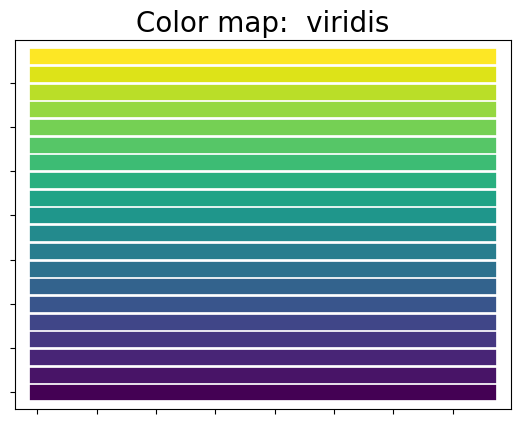

In [3]:
# change this variable to the name of the color map you're interested 
# in (as linked to in the text above)
cmapname = 'viridis'

# set this to True to get a grayscale image, False to get color images
grayify = False

# set this to True to write images to disk, False to not write files.
write_to_file = True

def grayify_cmap(cmap):
    """
    Return a grayscale version of the colormap.  
    C/O Jake VanderPlas. """
    cmap = plt.cm.get_cmap(cmap)
    colors = cmap(np.arange(cmap.N))
    
    # convert RGBA to perceived greyscale luminance
    # cf. http://alienryderflex.com/hsp.html
    RGB_weight = [0.299, 0.587, 0.114]
    luminance = np.sqrt(np.dot(colors[:, :3] ** 2, RGB_weight))
    colors[:, :3] = luminance[:, np.newaxis]
    
    return mpl_colors.LinearSegmentedColormap.from_list(cmap.name + "_grayscale", colors, cmap.N)

# sets number of lines.  If you mess with this, you need to change the
# linewidth in the plotting function below!
NCURVES = 20
curves = [i*np.ones(20) for i in range(NCURVES)]
values = range(NCURVES)

fig = plt.figure()

ax = fig.add_subplot(111)

# normalize colormap to the values listed above
cNorm  = mpl_colors.Normalize(vmin=0, vmax=values[-1])

# do I want a grayscale version of my color map?
if grayify:
    scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=grayify_cmap(cmapname))
else:
    scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmapname)
    
lines = []

# plot all of the lines together - this was hand-tuned a bit to get nice-looking images.
# if you adjust NCURVES you need to adjust linewidth
for idx in range(len(curves)):
    line = curves[idx]
    colorVal = scalarMap.to_rgba(values[idx])
    colorText = ('color: (%4.2f,%4.2f,%4.2f)'%(colorVal[0],colorVal[1],colorVal[2]))
    retLine, = ax.plot(line, color=colorVal, label=colorText, linewidth=11)
    lines.append(retLine)

# adjust title based on whether or not we're using a grayscale image
if grayify:
    mytitle = "Color map:  " + cmapname + "_grayscale"
else:
    mytitle = "Color map:  " + cmapname

plt.title(mytitle,fontsize=20)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

# write to a file if the user wants it!
if write_to_file:
    if grayify:
        filename = "colormap_" + cmapname + "_grayscale.png"
    else:
        filename = "colormap_" + cmapname + ".png"
    
    # print("Saving to file ", filename)
    # plt.savefig(filename)
